In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
df = pd.read_csv("/content/mnist_train.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (60000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_sample = df.sample(n=5000, random_state=42)

print("Sample shape:", df_sample.shape)

Sample shape: (5000, 785)


In [4]:
X = df_sample.drop("label", axis=1).values
y = df_sample["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 784)
y shape: (5000,)


In [5]:
X = X.astype("float32") / 255.0
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [6]:
X = X.reshape(-1, 28, 28, 1)

print("X shape after reshape:", X.shape)

X shape after reshape: (5000, 28, 28, 1)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (4000, 28, 28, 1)
Testing images: (1000, 28, 28, 1)


In [8]:
n_classes = len(np.unique(y))

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),

    Flatten(),

    Dense(64, activation="relu"),
    Dense(n_classes, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=32
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7531 - loss: 0.7874 - val_accuracy: 0.9050 - val_loss: 0.3598
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9417 - loss: 0.1887 - val_accuracy: 0.9525 - val_loss: 0.1802
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.9639 - loss: 0.1194 - val_accuracy: 0.9600 - val_loss: 0.1730
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9775 - loss: 0.0802 - val_accuracy: 0.9675 - val_loss: 0.1573
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9764 - loss: 0.0727 - val_accuracy: 0.9650 - val_loss: 0.1554


In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 0.9630
Test Accuracy: 96.30%


In [13]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


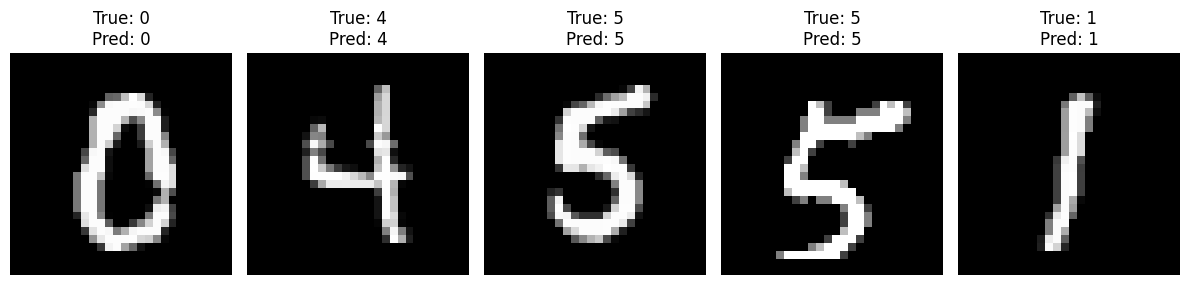

In [14]:
plt.figure(figsize=(12, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    plt.title(
        f"True: {y_test[i]}\nPred: {predicted_labels[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()